In [ ]:
!pip install sleap==1.2.0a0

In [ ]:
!pip install imgaug==0.2.9

In [ ]:
import sleap
import pandas as pd
import numpy as np

sleap.versions()

SLEAP: 1.2.0a0
TensorFlow: 2.7.0
Numpy: 1.19.5
Python: 3.7.12
OS: Linux-5.4.104+-x86_64-with-Ubuntu-18.04-bionic


In [ ]:
def flatten_features(x, axis=0):
    """Flatten multi-dimensional timeseries into 2D.

    Args:
        x: Timeseries of shape (time, ...) or with time axis specified by axis.
        axis: Time axis (default: 0).

    Returns:
        A tuple of (flat_x, initial_shape).

        flat_X is a timeseries with the time axis as axis 0 and all other dimensions
        flattened along the columns axis.

    See also: unflatten_features
    """
    if axis != 0:
        # Move time axis to the first dim
        x = np.moveaxis(x, axis, 0)

    # Flatten to 2D.
    initial_shape = x.shape
    x = x.reshape(len(x), -1)

    return x, initial_shape


def unflatten_features(x, initial_shape, axis=0):
    """Unflatten 2D timeseries into multi-dimensional timeseries.

    Args:
        x: Timeseries of shape (time, ...).
        initial_shape: The shape before flattening.
        axis: Time axis (default: 0).

    Returns:
        Timeseries with the time axis in the specified axis and the

    See also: flatten_features
    """
    # Reshape.
    x = x.reshape(initial_shape)

    if axis != 0:
        # Move time axis back
        x = np.moveaxis(x, 0, axis)

    return x


def fill_missing(x, kind="nearest", axis=0, limit=None, **kwargs):
    """Fill missing values in a timeseries.

    Args:
        x: Timeseries of shape (time, ...) or with time axis specified by axis.
        kind: Type of interpolation to use. Defaults to "nearest".
        axis: Time axis (default: 0).
        limit: Number of NaNs to fill in a row or None for no limit (default: None).

    Returns:
        Timeseries of the same shape as the input with NaNs filled in.

    Notes:
        This uses pandas.DataFrame.interpolate and accepts the same kwargs.
    """
    if x.ndim > 2:
        # Reshape to (time, D)
        x, initial_shape = flatten_features(x, axis=axis)

        # Interpolate.
        x = fill_missing(x, kind=kind, axis=0, **kwargs)

        # Restore to original shape
        x = unflatten_features(x, initial_shape, axis=axis)

        return x

    return pd.DataFrame(x).interpolate(method=kind, axis=axis, limit=limit, **kwargs).to_numpy()


def smooth_ewma(x, alpha, axis=0, inplace=False):
    """Smooth using exponentially weighted moving average filter.

    Args:
        x: Timeseries of shape (time, ...) or with time axis specified by axis.
        alpha: Smoothing factor between 0 and 1, where higher values result in a smaller
            contribution from adjacent timesteps.
        axis: Time axis (default: 0).
        inplace: If True, do not make a copy before smoothing.

    Returns:
        Timeseries of the same shape as the input with smoothing applied.

    See also: pandas.DataFrame.ewm.
    """
    if axis != 0 or x.ndim > 1:
        if not inplace:
            x = x.copy()

        # Reshape to (time, D)
        x, initial_shape = flatten_features(x, axis=axis)

        # Apply function to each slice
        for i in range(x.shape[1]):
            x[:, i] = smooth_ewma(x[:, i], alpha, axis=0)

        # Restore to original shape
        x = unflatten_features(x, initial_shape, axis=axis)
        return x
    initial_shape = x.shape
    x = pd.DataFrame(x).ewm(alpha=alpha, axis=axis).mean().to_numpy()
    return x.reshape(initial_shape)


def smooth_gaussian(x, std=1.0, window=5, axis=0, inplace=False):
    """Smooth using moving Gaussian filter.

    Args:
        x: Timeseries of shape (time, ...) or with time axis specified by axis.
        std: Standard deviation of the gaussian filter (default: 1.0).
        window: Width of the temporal filter in timesteps (default: 5).
        axis: Time axis (default: 0).
        inplace: If True, do not make a copy before smoothing.

    Returns:
        Timeseries of the same shape as the input with smoothing applied.

    See also: pandas.DataFrame.rolling.
    """
    if axis != 0 or x.ndim > 1:
        if not inplace:
            x = x.copy()

        # Reshape to (time, D)
        x, initial_shape = flatten_features(x, axis=axis)

        # Apply function to each slice
        for i in range(x.shape[1]):
            x[:, i] = smooth_gaussian(x[:, i], std, window, axis=0)

        # Restore to original shape
        x = unflatten_features(x, initial_shape, axis=axis)
        return x

    y = pd.DataFrame(x.copy()).rolling(window, win_type="gaussian", center=True).mean(std=std).to_numpy()
    y = y.reshape(x.shape)
    mask = np.isnan(y) & (~np.isnan(x))
    y[mask] = x[mask]
    return y


def smooth_median(x, window=5, axis=0, inplace=False):
    """Smooth using moving median filter.

    Args:
        x: Timeseries of shape (time, ...) or with time axis specified by axis.
        window: Width of the temporal filter in timesteps (default: 5).
        axis: Time axis (default: 0).
        inplace: If True, do not make a copy before smoothing.

    Returns:
        Timeseries of the same shape as the input with smoothing applied.

    See also: pandas.DataFrame.rolling.
    """
    if axis != 0 or x.ndim > 1:
        if not inplace:
            x = x.copy()

        # Reshape to (time, D)
        x, initial_shape = flatten_features(x, axis=axis)

        # Apply function to each slice
        for i in range(x.shape[1]):
            x[:, i] = smooth_median(x[:, i], window, axis=0)

        # Restore to original shape
        x = unflatten_features(x, initial_shape, axis=axis)
        return x

    y = pd.DataFrame(x.copy()).rolling(window, win_type=None, center=True).median().to_numpy()
    y = y.reshape(x.shape)
    mask = np.isnan(y) & (~np.isnan(x))
    y[mask] = x[mask]
    return y

In [ ]:
from google.colab import files
uploads = files.upload()
labels_path = list(uploads.keys())[0]

Saving 2020-3-10_daytime_5mins_compressedTalmo@3200-5760.slp to 2020-3-10_daytime_5mins_compressedTalmo@3200-5760 (1).slp


In [ ]:
labels_old = sleap.load_file(labels_path)
labels_old

Labels(labeled_frames=2560, videos=1, skeletons=1, tracks=4)

In [ ]:
# Labels -> numpy
raw_trx = labels_old.numpy(all_frames=False)
raw_trx.shape

(2560, 4, 14, 2)

In [ ]:
trx = raw_trx.copy()

# Fill missing with linear interpolation up to 5 frames away
trx = fill_missing(trx, kind="linear", limit=5)

# Smooth with median to get rid of discrete jumps
trx = smooth_median(trx, window=5)

# Smooth with EWMA to get softer trajectories
trx = smooth_ewma(trx, alpha=0.7)

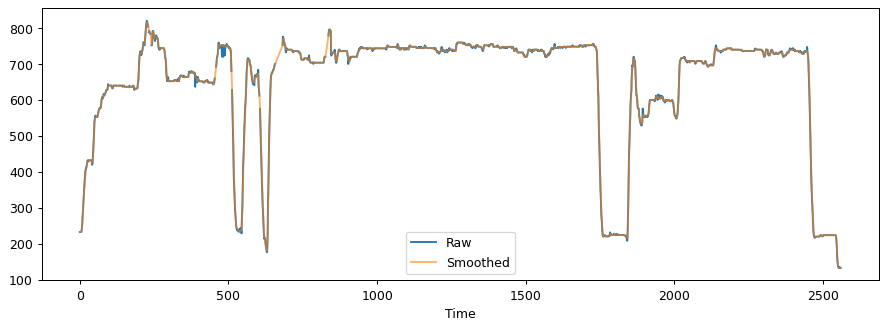

In [ ]:
# Visualize traces
import matplotlib.pyplot as plt

j = labels_old.skeleton.node_names.index("spine3")

plt.figure(figsize=(12, 4), dpi=90)
plt.plot(raw_trx[:, 0, j, 1], "-", label="Raw")
plt.plot(trx[:, 0, j, 1], "-", alpha=0.6, label="Smoothed")
plt.legend()
plt.xlabel("Time");

In [ ]:
# numpy -> Labels
lfs = []
for t, poses in enumerate(trx):
    instances = []
    for pose, track in zip(poses, labels_old.tracks):
        instances.append(
            sleap.Instance.from_numpy(pose, skeleton=labels_old.skeleton, track=track)
        )
    lfs.append(sleap.LabeledFrame(video=labels_old[t].video, frame_idx=t, instances=instances))
labels_new = sleap.Labels(lfs)

labels_new

Labels(labeled_frames=2560, videos=1, skeletons=1, tracks=4)

In [ ]:
new_path = f"{labels_path[:-4]}.smoothed.slp"
labels_new.save(new_path)

files.download(new_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>